In [1]:
from mushroom_rl.environments import LQR
from mushroom_rl.solvers.lqr import *
import jax
import jax.numpy as jnp
jax.config.update('jax_default_matmul_precision', 'float32')

STATE_DIM,A_DIM = 4,2
env = LQR.generate(s_dim=STATE_DIM,a_dim=A_DIM,gamma=0.99,episodic=True,horizon=500,random_init=True)

/home/mahdi/Desktop/supersac/.venv/lib/python3.10/site-packages/gym/wrappers/monitoring/video_recorder.py:9: DeprecationWarning: The distutils package is deprecated and slated for removal in Python 3.12. Use setuptools or check PEP 632 for potential alternatives
  import distutils.spawn


In [2]:
def evaluate_critic(agent,test_transitions):
    
    
    K = np.array(agent.actor.params['means']['kernel'])
    noise = jnp.diag(jnp.exp(agent.actor.params['log_stds']))# For state dependant noise but i think formulation is without
    
    Q_true = []
    
    for obs,action in zip(test_transitions["observations"],test_transitions["actions"]):
        
        Q_true.append(compute_lqr_Q_gaussian_policy(obs,action,env,-K.T,noise))
    
    Q_true = jnp.array(Q_true)
    
    Q = agent.critic(test_transitions["observations"],test_transitions["actions"]).mean(axis=0)
    
    return jnp.sqrt((Q-Q_true)**2).mean(), (Q-Q_true).mean()
    
    
    

In [3]:
# test_transitions = test_buffer.get_all()
# K = np.array(agent.actor.params['means']['kernel'])
# noise = jnp.diag(jnp.exp(agent.actor.params['log_stds']))# For state dependant noise but i think formulation is without

# Q_true = []

# for obs,action in zip(test_transitions["observations"],test_transitions["actions"]):
    
#     #Q_true.append(compute_lqr_Q_gaussian_policy(obs,action,env,-K.T,noise))
#     Q_true.append(compute_lqr_Q(obs,action,env,-K.T))

# Q_true = jnp.array(Q_true)

# Q = agent.critic(test_transitions["observations"],test_transitions["actions"]).mean(axis=0)

# jnp.sqrt((Q-Q_true)**2).mean(), (Q-Q_true).mean()



In [4]:
# %%

import os
import wandb
import argparse
import itertools
import numpy as np
import jax
import jax.numpy as jnp
from jaxrl_m.common import CodeTimer
import logging
import envpool
logging.basicConfig(level=logging.CRITICAL)


def get_batch(i,batches):
    return  jax.tree.map(lambda x: x[i], batches)

def body(i,val):
    agent,batches = val
    return (agent.update_critics(get_batch(i,batches)),batches)

def str2bool(v):
    if isinstance(v, bool):
        return v
    if v.lower() in ('yes', 'true', 't', 'y', '1'):
        return True
    elif v.lower() in ('no', 'false', 'f', 'n', '0'):
        return False
    else:
        raise argparse.ArgumentTypeError('Boolean value expected.')
    

def none_or_str(value):
    if value == 'None':
        return None
    return value

# Set env variables
os.environ["WANDB_API_KEY"]="28996bd59f1ba2c5a8c3f2cc23d8673c327ae230"
os.environ['PYTHONHASHSEED'] = '1'
os.environ['TF_CUDNN_DETERMINISTIC'] = '1'

##############################
parser = argparse.ArgumentParser()

parser.add_argument('--seed',type=int,default=42) 

parser.add_argument('--algo_name', type=str, default='superppo', help='the name of the RL algorithm')
parser.add_argument('--project_name',type=str,default="single_exp") 

parser.add_argument('--env_name',type=str,default="Hopper-v5") 
parser.add_argument('--max_steps',type=int,default=100_000) 
parser.add_argument('--max_episode_steps',type=int,default=500) 
parser.add_argument('--num_rollouts',type=int,default=4) 
parser.add_argument('--gamma',type=float,default=0.99)
parser.add_argument('--healthy_reward',type=float,default=1.) 
parser.add_argument('--entropy_coeff',type=float,default=1.) 

parser.add_argument('--discount_actor',type=str2bool,default=True)
parser.add_argument('--min_target',type=str2bool,default=False)
parser.add_argument('--discount_entropy',type=str2bool,default=True) 
parser.add_argument('--on_policy_data',type=str2bool,default=False)
parser.add_argument('--adaptive_critics',type=str2bool,default=False) 
parser.add_argument('--num_critics',type=int,default=2)

parser.add_argument('--critic_lr',type=float,default=3e-4) 
parser.add_argument('--actor_lr',type=float,default=3e-4) 
parser.add_argument('--temp_lr',type=float,default=3e-4)
parser.add_argument('--use_layer_norm',type=str2bool,default=True)

parser.add_argument('--momentum',type=float,default=0.) 
parser.add_argument('--num_actor_updates',type=int,default=5) 
parser.add_argument('--clipping_ratio',type=float,default=0.1) 
parser.add_argument('--hidden_dims',type=int,default=64) 
parser.add_argument('--episode_based',type=str2bool,default=False) 
parser.add_argument('--tanh_squash_actions',type=str2bool,default=True) 


args = parser.parse_args(args=[])

from jaxrl_m.onsac_clean import *

hidden_dims = ()
NUM_UPDATES = 1000
data = []

import os
from functools import partial
import numpy as np
import jax
import tqdm
import gymnasium as gym


from jaxrl_m.wandb import setup_wandb, default_wandb_config, get_flag_dict
import wandb
from jaxrl_m.evaluation import supply_rng, evaluate, flatten, EpisodeMonitor
from jaxrl_m.dataset import ReplayBuffer,ActorReplayBuffer
from collections import deque
from jax import config
from jaxrl_m.utils import flatten_rollouts
from jaxrl_m.evaluate_critic import evaluate_many_critics
from jaxrl_m.rollout import rollout_policy_lqr
from jax import config
import copy 


config.update("jax_debug_nans", True)

eval_episodes=10
batch_size = 256
max_steps = args.max_steps
start_steps = 0
log_interval = 10000
n_grads = 0


observation = jnp.ones(env._mdp_info.observation_space.shape)
action = jnp.ones(env._mdp_info.action_space.shape)


example_transition = dict(
    observations=observation,
    actions=action,
    rewards=0.0,
    masks=1.0,
    next_observations=observation,
    pre_actions = action,
    discounts=1.0,
    log_probs=0.,
)
buffer_size = args.num_rollouts*args.max_episode_steps if args.on_policy_data else 100_000
replay_buffer = ReplayBuffer.create(example_transition, size=int(buffer_size))
actor_buffer = ActorReplayBuffer.create(example_transition, size=int(args.num_rollouts*args.max_episode_steps))
test_buffer = ActorReplayBuffer.create(example_transition, size=int(args.num_rollouts*args.max_episode_steps))



args_dict = {

"seed": args.seed,
"observations":example_transition['observations'][None],
"actions":example_transition['actions'][None],
"max_steps":max_steps,
"discount":args.gamma,
"discount_actor":args.discount_actor,
"min_target":args.min_target,
"discount_entropy":args.discount_entropy,
"adaptive_critics":args.adaptive_critics,
"num_critics": args.num_critics,
"entropy_coeff":args.entropy_coeff,
"temp_lr":args.temp_lr,
"actor_lr":args.actor_lr,
"critic_lr":args.critic_lr,
"momentum":args.momentum,
"clipping_ratio":args.clipping_ratio,
"num_actor_updates":args.num_actor_updates,
"critic_hidden_dims":(args.hidden_dims,args.hidden_dims),
"actor_hidden_dims":(),
"use_layer_norm": args.use_layer_norm,
"state_dependent_std":False,
"tanh_squash_distribution":False,
"tanh_squash_actions":False,
"use_bias":False,

}

args_dict_min = copy.deepcopy(args_dict)
args_dict_min["min_target"]=True
agent = create_learner(**args_dict)
agent_on = create_learner(**args_dict)
agent_min = create_learner(**args_dict_min)

##############




exploration_metrics = dict()
#obs,info = env.reset()    
exploration_rng = jax.random.PRNGKey(0)
i = 0
unlogged_steps,cached_steps = 0,0
policy_rollouts = deque([], maxlen=20)
warmup = True
R2,bias = jnp.ones(args.num_critics),jnp.zeros(args.num_critics)



with tqdm.tqdm(total=max_steps) as pbar:
    
    while (i < max_steps):
        with jax.log_compiles(False):
            warmup=(i < start_steps)
            
            logging.debug('policy rollout')
            replay_buffer,actor_buffer,policy_rollout,policy_return,variance,undisc_policy_return,num_steps = rollout_policy_lqr(
                                                                    agent,env,exploration_rng,
                                                                    replay_buffer,actor_buffer,eval=False,
                                                                    num_rollouts=args.num_rollouts,discount = args.gamma,max_length=args.max_episode_steps)
            
            
            
            
            _,test_buffer,_,_,_,_,_ = rollout_policy_lqr(
                                                                    agent,env,exploration_rng,
                                                                    None,test_buffer,eval=False,
                                                                    num_rollouts=args.num_rollouts,discount = args.gamma,max_length=args.max_episode_steps)
            
            
            print(f'policy_return: {policy_return}, undisc_policy_return {undisc_policy_return}')                                                              
            if not warmup : policy_rollouts.append(policy_rollout)
            unlogged_steps += num_steps
            cached_steps += num_steps
            i+=num_steps
            pbar.update(int(num_steps))
            
            if replay_buffer.size > start_steps:
            
                ### Update critics ###:
                logging.debug('update critics')
                transitions = replay_buffer.get_all()
                idxs = jax.random.choice(agent.rng,a=transitions['observations'].shape[0], shape=(NUM_UPDATES,256), replace=True)
                batches = jax.vmap(lambda i: jax.tree.map(lambda x: x[i], transitions))(idxs)
                agent = agent.update_critics_seq(batches,R2)
                agent_min = agent_min.update_critics_seq(batches,R2)
                
                a,b=evaluate_critic(agent,test_buffer.get_all())
                c,d=evaluate_critic(agent_min,test_buffer.get_all())
                
                print(a,b,c,d)
                data.append((a,b,c,d))

                ### Update actor ###
                actor_batch = actor_buffer.get_all()    
                agent, actor_update_info = agent.update_actor(actor_batch,R2)    
                critic_update_info = {}
                update_info = {**critic_update_info, **actor_update_info}
                n_grads += 1
                
        
                             
                
                ### Log training info ###
                exploration_metrics = {f'exploration/disc_return': policy_return,'training/std': jnp.sqrt(variance)}
                train_metrics = {f'training/{k}': v for k, v in update_info.items()}
                train_metrics['training/undisc_return'] = undisc_policy_return
                                    
            
                if cached_steps >= int(1e6): 
                    jax.clear_caches()
                    cached_steps = 0
                    print('clearing cache')
        


/home/mahdi/Desktop/supersac/.venv/lib/python3.10/site-packages/wandb/util.py:152: SentryHubDeprecationWarning: `sentry_sdk.Hub` is deprecated and will be removed in a future major release. Please consult our 1.x to 2.x migration guide for details on how to migrate `Hub` usage to the new API: https://docs.sentry.io/platforms/python/migration/1.x-to-2.x
  sentry_hub = sentry_sdk.Hub(sentry_client)
2024-09-20 11:20:48.059152: W external/xla/xla/service/gpu/nvptx_compiler.cc:836] The NVIDIA driver's CUDA version is 12.5 which is older than the PTX compiler version (12.6.68). Because the driver is older than the PTX compiler version, XLA is disabling parallel compilation, which may slow down compilation. You should update your NVIDIA driver or use the NVIDIA-provided CUDA forward compatibility packages.


Extra kwargs: {'max_steps': 100000}
Extra kwargs: {'max_steps': 100000}
Extra kwargs: {'max_steps': 100000}


  2%|▏         | 2000/100000 [00:01<01:37, 1004.60it/s]

policy_return: -744.830166439053, undisc_policy_return -10547.14319627337
2493.8962 2493.8962 2493.8696 2493.8696


  4%|▍         | 4000/100000 [00:21<09:47, 163.52it/s] 

...

policy_return: -335.3094488145289, undisc_policy_return -1609.3011981600544
34.35661 -20.707869 158.69492 -46.90188


100%|██████████| 100000/100000 [11:58<00:00, 138.63it/s]

policy_return: -284.2962835420278, undisc_policy_return -1266.7889913527238


100%|██████████| 100000/100000 [12:10<00:00, 136.83it/s]

97.86009 23.344608 310.5253 174.73059


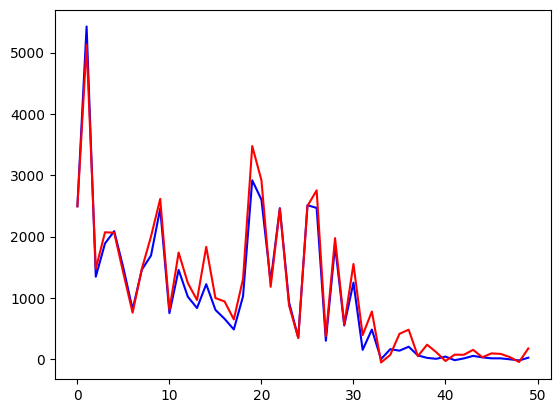

In [5]:
import matplotlib.pyplot as plt


plt.plot([i[1] for i in data],color="blue")
plt.plot([i[3] for i in data],color="red")


In [10]:
import copy
from jaxrl_m.networks import OriginalCritic

rng = jax.random.PRNGKey(42)

args_dict2 = copy.deepcopy(args_dict)
args_dict2["on_policy_data"]=True
agent_on = create_learner(**args_dict)
agent_off = create_learner(**args_dict2)

transitions = actor_buffer.get_all()
idxs = jax.random.choice(agent.rng,a=transitions['observations'].shape[0], shape=(NUM_UPDATES,256), replace=True)
batches = jax.vmap(lambda i: jax.tree.map(lambda x: x[i], transitions))(idxs)

agent_on.actor.params['log_stds'] = -100 * jnp.ones_like(agent_on.actor.params['log_stds'])
agent_on.actor.params['means']['kernel'] = jnp.copy(agent.actor.params['means']['kernel'])
agent_on = agent_on.update_critics_seq(batches,R2)

################################################

transitions = replay_buffer.get_all()
idxs = jax.random.choice(agent.rng,a=transitions['observations'].shape[0], shape=(NUM_UPDATES,256), replace=True)
batches = jax.vmap(lambda i: jax.tree.map(lambda x: x[i], transitions))(idxs)

agent_off.actor.params['log_stds'] = -100 * jnp.ones_like(agent_off.actor.params['log_stds'])
agent_off.actor.params['means']['kernel'] = jnp.copy(agent.actor.params['means']['kernel'])
agent_off = agent_off.update_critics_seq(batches,R2)

Extra kwargs: {'max_steps': 100000}
Extra kwargs: {'max_steps': 100000, 'on_policy_data': True}


In [11]:
transitions = test_buffer.get_all()
#transitions = replay_buffer.get_all()
#transitions = jax.tree.map(lambda x:x[:10000],transitions)
params_on = {'params':agent_on.critic.params}
params_on = jax.tree.map(lambda x:x[0],params_on)
params_off = {'params':agent_off.critic.params}
params_off = jax.tree.map(lambda x:x[0],params_off)
_,tmp_on= OriginalCritic(hidden_dims=(args.hidden_dims,args.hidden_dims)).apply(params_on,transitions["observations"],transitions["actions"],mutable='intermediates')
_,tmp_off= OriginalCritic(hidden_dims=(args.hidden_dims,args.hidden_dims)).apply(params_off,transitions["observations"],transitions["actions"],mutable='intermediates')

embeds_on = tmp_on['intermediates']['features'][0]
embeds_off = tmp_off['intermediates']['features'][0]

@jax.jit
def pairwise_euclidean(x, y):
  assert x.ndim == y.ndim == 2
  return jnp.sqrt(((x[:, None, :] - y[None, :, :]) ** 2).sum(-1))

dist_on = pairwise_euclidean(embeds_on.squeeze(),embeds_on.squeeze())
dist_off = pairwise_euclidean(embeds_off.squeeze(),embeds_off.squeeze())

print(dist_on.mean(),dist_off.mean())

6.473185 0.22555499


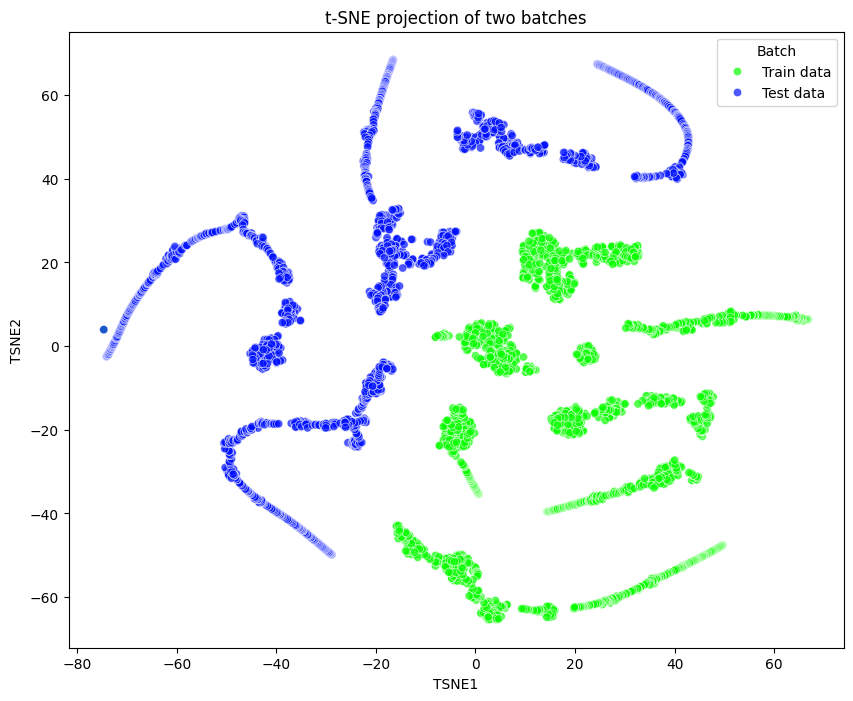

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import seaborn as sns



def plot_embeds(agent,train_transitions,test_transitions):

    params = {'params':agent.critic.params}
    params = jax.tree.map(lambda x:x[0],params)
    
    _,train_embeds= OriginalCritic(hidden_dims=(args.hidden_dims,args.hidden_dims)).apply(params,train_transitions["observations"],train_transitions["actions"],mutable='intermediates')
    _,test_embeds= OriginalCritic(hidden_dims=(args.hidden_dims,args.hidden_dims)).apply(params,test_transitions["observations"],test_transitions["actions"],mutable='intermediates')

    train_embeds = train_embeds['intermediates']['features'][0]
    test_embeds = test_embeds['intermediates']['features'][0]


    # Perform t-SNE on both batches
    tsne = TSNE(n_components=2, random_state=0)
    tsne_results = tsne.fit_transform(jnp.vstack([train_embeds,test_embeds]))
    # pca = PCA(n_components=2)
    # tsne_results = pca.fit_transform(jnp.vstack([train_embeds,test_embeds]))
    
    tsne_results1,tsne_results2 = tsne_results[:2000],tsne_results[2000:]

    # Create a DataFrame for plotting
    df1 = pd.DataFrame(tsne_results1, columns=['TSNE1', 'TSNE2'])
    df1['Batch'] = 'Train data'
    df2 = pd.DataFrame(tsne_results2, columns=['TSNE1', 'TSNE2'])
    df2['Batch'] = 'Test data'

    # Combine the DataFrames
    df = pd.concat([df1, df2])

    # Plot the results
    plt.figure(figsize=(10, 8))
    sns.scatterplot(
        x='TSNE1', y='TSNE2',
        hue='Batch',
        palette=sns.color_palette("hsv", 2),
        data=df,
        legend="full",
        alpha=0.7
    )
    plt.title('t-SNE projection of two batches')
    plt.show()



train_transitions = actor_buffer.get_all()
test_transitions = test_buffer.get_all()

plot_embeds(agent_on,train_transitions,test_transitions)

In [1]:
jax.config.update('jax_default_matmul_precision', 'highest')
obs = env.reset()

K = np.array(agent.actor.params['means']['kernel'])
noise = jnp.diag(jnp.exp(agent.actor.params['log_stds']))# For state dependant noise but i think formulation is without
K_ref= compute_lqr_feedback_gain(env)

########################################
reference = compute_lqr_V(obs,env,K_ref)
V = compute_lqr_V(obs,env,-K.T)
V_noise = compute_lqr_V_gaussian_policy(obs,env,-K.T,noise)
reference_noise = compute_lqr_V_gaussian_policy(obs,env,K_ref,noise)
print(f'Reference {reference} Reference_noise {reference_noise}')

total = 0
gamma = 1
exploration_rng = jax.random.PRNGKey(52)

print(f'V {V} V_noise {V_noise}')

for i in range(500):

    exploration_rng, key = jax.random.split(exploration_rng)
    action,_,_ = agent.sample_actions(obs,seed=exploration_rng)
    print(action)
    # action = agent.deterministic_action(obs)
    # action = K.T@obs
    next_obs, reward, done, info = env.step(action)  
    #obs = next_obs
    total+=gamma*reward
    gamma *= 0.99
    
print(total)


NameError: name 'jax' is not defined